In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model  import LinearRegression

In [2]:
df = pd.read_csv("salary_data.csv")

In [5]:
df.shape

(30, 2)

In [6]:
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [8]:
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

In [9]:
df = df.dropna()

In [10]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [9]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [10]:
X = df["YearsExperience"]
y = df["Salary"]

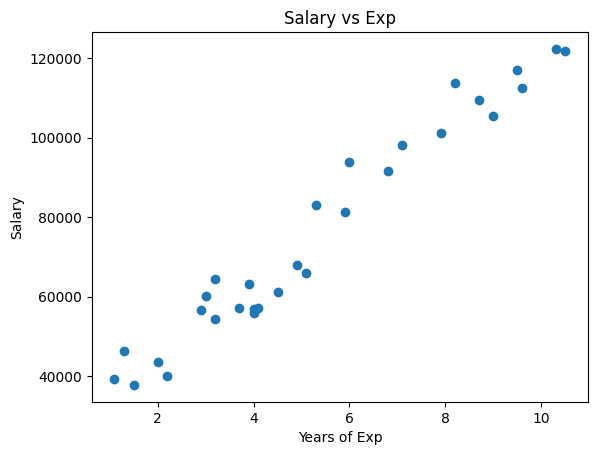

In [11]:
plt.scatter(X,y)
plt.xlabel("Years of Exp")
plt.ylabel("Salary")
plt.title("Salary vs Exp")
plt.show()

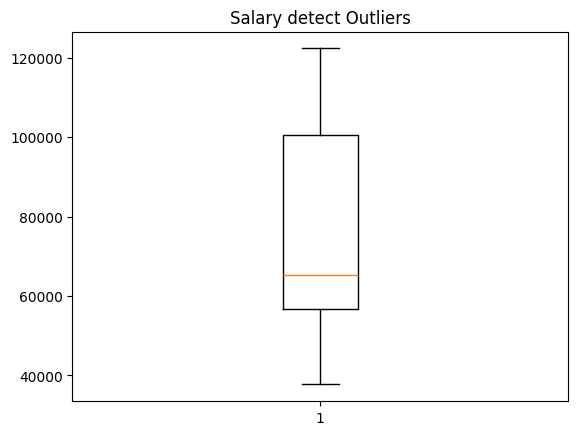

In [12]:
# check the outliear detection 
plt.boxplot(df["Salary"])
plt.title("Salary detect Outliers")
plt.show()

In [13]:
df.dtypes

YearsExperience    float64
Salary             float64
dtype: object

In [15]:
df[["YearsExperience","Salary"]].corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


In [16]:
X = df["YearsExperience"].values.reshape(-1,1) # Independent Variable
y = df["Salary"].values # dependent variable 

In [17]:
model = LinearRegression()
model.fit(X,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
m = model.coef_[0]
b = model.intercept_

In [21]:
print("Slope (m): ",m)
print("Intercept (b): ",b)

Slope (m):  6844.510514484165
Intercept (b):  31921.21691704422


In [22]:
y_pred = model.predict(X)

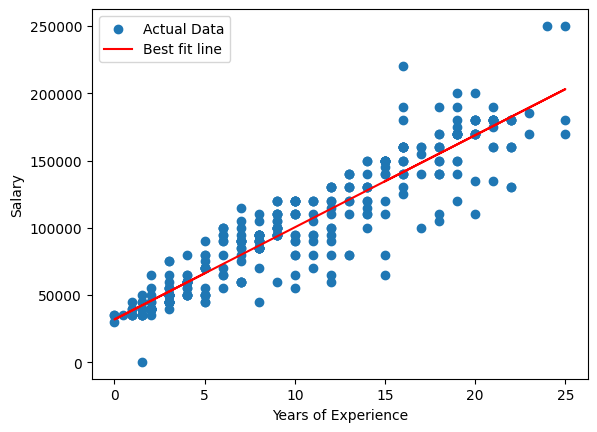

In [23]:
plt.scatter(X,y,label="Actual Data")
plt.plot(X,y_pred,label = "Best fit line",color = "red")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()

In [25]:
# Residula Analysis 
# Residual = y -y^

residual = y-y_pred

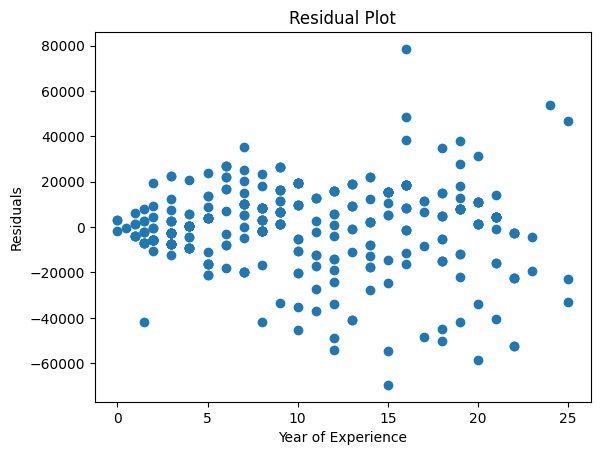

In [26]:
plt.scatter(X,residual)
# print("Residual: ",residual)
plt.xlabel("Year of Experience")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [27]:
# Measure Accuracy Using R² Score
from sklearn.metrics import r2_score
r2 = r2_score(y,y_pred)
print("R2 Score:",r2)

R2 Score: 0.865528278393677


In [28]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y,y_pred)
print("MSE: ",mse)

MSE:  312090043.799001


In [29]:
# convert mse --> rmse
rmse = np.sqrt(mse)
rmse

np.float64(17666.070411922425)

In [30]:
# Make Real-Life Predictions
experience = 3
predicted_salary = model.predict([[experience]])
print("Predicted Salary: ",predicted_salary[0])

Predicted Salary:  52454.74846049672


Iteration 0, Loss: 12.666666666666666
Iteration 100, Loss: 0.06219036003148121
Iteration 200, Loss: 0.05965546135103804
Iteration 300, Loss: 0.058089048373429944
Iteration 400, Loss: 0.0571211002725326
Iteration 500, Loss: 0.05652296712410737
Iteration 600, Loss: 0.05615335715957183
Iteration 700, Loss: 0.05592496064577919
Iteration 800, Loss: 0.055783825469464046
Iteration 900, Loss: 0.055696612500830085
Final slope (m): 1.4891565847482928
Final intercept (b): 0.3579829649416946


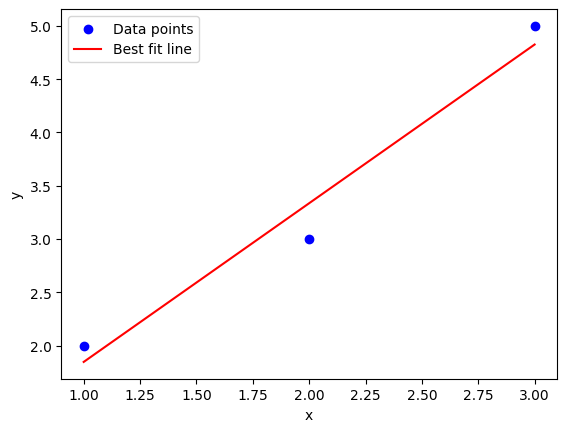

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sample data (x, y)
x = np.array([1, 2, 3])
y = np.array([2, 3, 5])

# Initialize parameters
m = 0  # slope
b = 0  # intercept
learning_rate = 0.01
iterations = 1000
n = len(x)  # number of data points

# Gradient descent loop
for i in range(iterations):
    # Predicted values
    y_pred = m * x + b
    
    # Calculate gradients
    dm = (-2/n) * sum(x * (y - y_pred))
    db = (-2/n) * sum(y - y_pred)
    
    # Update parameters
    m = m - learning_rate * dm
    b = b - learning_rate * db
    
    # Optional: Print loss to see if it’s decreasing
    loss = (1/n) * sum((y - y_pred)**2)
    if i % 100 == 0:
        print(f"Iteration {i}, Loss: {loss}")

# Print final parameters
print(f"Final slope (m): {m}")
print(f"Final intercept (b): {b}")

# Plot the data and the regression line
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, m*x + b, color='red', label='Best fit line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
